# 1. Imports and Setup

In [1]:
import sys
import os
from collections import defaultdict

# Add the src directory to sys.path
sys.path.append(os.path.abspath("../src"))

import torch
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, Markdown

from abstractions.dsl.abstraction import Abstraction
from abstractions.dsl.core import Shape
from abstractions.data.generator import generate_dataset
from abstractions.learning.utils import add, get_singletons, get_pairs
from abstractions.primitives.visualization import show_boxes, print_tree
from abstractions.learning.abstraction_discovery import find_abstractions, integrate_abstractions
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 2. Utility and Helper Functions

In [2]:
def count_nodes(shape):
    """Recursively counts the number of nodes in a shape program."""
    if not hasattr(shape, "param_tuple"):
        return 1
    _, args = shape.param_tuple()
    return 1 + sum(count_nodes(arg) for arg in args)

def contains_abstraction(shape):
    """Recursively checks if a shape program contains an Abstraction node."""
    if isinstance(shape, Abstraction):
        return True
    if not hasattr(shape, 'param_tuple'):
        return False
    _, args = shape.param_tuple()
    return any(contains_abstraction(arg) for arg in args)

def extract_float_params(param_list):
    """Extracts only float or integer parameters from a list of parameter tuples."""
    return [
        [p for p in tup if isinstance(p, (float, int))]
        for tup in param_list
    ]

def make_df_from_structure(param_list):
    """Converts a list of parameters into a Pandas DataFrame with float columns."""
    float_data = extract_float_params(param_list)
    float_data = [row for row in float_data if len(row) > 0]
    if not float_data:
        return pd.DataFrame()
    
    df = pd.DataFrame(float_data)
    df.columns = [f"param_{i}" for i in range(df.shape[1])]
    return df

# 3. Reusable Visualization Widgets

In [3]:
def visualize_dataset_interactive(dataset):
    """Creates an interactive slider to view shapes in a dataset."""
    output = widgets.Output()
    index_slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset) - 1, step=1,
        description='Shape Index:', continuous_update=False
    )

    def update_display(change):
        idx = change["new"]
        output.clear_output()
        with output:
            shape = dataset[idx]
            display(Markdown(f"### Shape #{idx}"))
            print_tree(shape)
            show_boxes(shape.get_box_list(), backend="plotly")

    index_slider.observe(update_display, names="value")
    display(Markdown("### Visualize Dataset"), index_slider, output)
    update_display({"new": 0}) # Initial display

def create_structure_scatterplot_widget(structures, title):
    """Creates a dropdown to generate scatter plots for different structures."""
    plot_dropdown = widgets.Dropdown(
        options=list(structures.keys()),
        description="Structure:",
        layout=widgets.Layout(width="60%"),
    )
    plot_output = widgets.Output()

    def plot_on_change(change):
        structure_name = change["new"]
        plot_output.clear_output()
        with plot_output:
            param_list = structures[structure_name]
            df = make_df_from_structure(param_list)
            display(Markdown(f"### `{structure_name}` – {len(df)} instances"))
            if df.empty or df.shape[1] == 0:
                print("No float parameters to visualize.")
                return
            
            fig = px.scatter(
                df, x="param_0", y="param_1" if df.shape[1] > 1 else None,
                title=f"Scatterplot of parameters for {structure_name}",
                hover_data=df.columns
            ) if df.shape[1] > 1 else px.histogram(df, x="param_0", nbins=50, title=f"Histogram for {structure_name}")
            fig.show()

    plot_dropdown.observe(plot_on_change, names="value")
    display(Markdown(f"### {title}"), plot_dropdown, plot_output)
    if list(structures.keys()):
        plot_dropdown.value = list(structures.keys())[0]

def create_reconstruction_plot_widget(models, structures, threshold):
    """Creates a widget to visualize model reconstruction error."""
    dropdown = widgets.Dropdown(options=list(models.keys()), description="Structure:")
    output = widgets.Output()

    def update_plot(change):
        name = change["new"]
        output.clear_output()
        with output:
            model = models[name]
            param_list = structures[name]
            df = make_df_from_structure(param_list)
            if df.empty:
                print("No float parameters to plot.")
                return

            data = torch.tensor(df.values, dtype=torch.float32)
            model.eval()
            with torch.no_grad():
                _, recon = model(data)
                error = torch.max(torch.abs(recon - data), dim=1)[0]
                df["well_explained"] = error < threshold
            
            fig = px.scatter(
                df, x="param_0", y="param_1", color="well_explained",
                color_discrete_map={True: "green", False: "red"},
                title=f"{name} — Reconstruction Quality (Error < {threshold})"
            )
            fig.show()

    dropdown.observe(update_plot, names="value")
    display(Markdown("### Well-Defined Plots (Reconstruction Quality)"), dropdown, output)
    if list(models.keys()):
        update_plot({"new": dropdown.value})

def create_comparison_widget(original_dataset, abstracted_dataset):
    """Creates a widget to compare original and abstracted shapes."""
    num_before = sum(count_nodes(s) for s in original_dataset)
    num_after = sum(count_nodes(s) for s in abstracted_dataset)
    abstracted_indices = [i for i, s in enumerate(abstracted_dataset) if contains_abstraction(s)]
    
    summary = f"Total nodes reduced from {num_before} to {num_after}. "
    summary += f"{len(abstracted_indices)} / {len(original_dataset)} shapes were abstracted."
    display(Markdown(f"### Before and After Abstraction\n**Summary:** {summary}"))

    options = [
        (f"Index {i} | Δ={count_nodes(original_dataset[i]) - count_nodes(s)}", i)
        for i, s in enumerate(abstracted_dataset) if i in abstracted_indices
    ]
    if not options:
        print("No shapes were successfully abstracted.")
        return

    dropdown = widgets.Dropdown(options=options, description="Shape:")
    output = widgets.Output()

    def show_comparison(idx):
        output.clear_output()
        with output:
            before, after = original_dataset[idx], abstracted_dataset[idx]
            display(Markdown(f"#### Comparing Shape Index: {idx}"))
            print(f"Node Count: {count_nodes(before)} → {count_nodes(after)}")
            
            print("\nOriginal DSL Tree:")
            #print_tree(before)
            print(before)
            print("\nAbstracted DSL Tree:")
            #print_tree(after)
            print(after)
            
            display(Markdown("##### Original Geometry"))
            show_boxes(before.get_box_list(), backend="plotly")
            display(Markdown("##### Abstracted Geometry"))
            show_boxes(after.get_box_list(), backend="plotly")
            
    dropdown.observe(lambda change: show_comparison(change["new"]), names="value")
    display(dropdown, output)
    show_comparison(options[0][1])


# 4. Initial Abstraction

In [4]:
# 1.1. Generate and Visualize Dataset
print("--- PHASE 1: INITIAL ABSTRACTION ---")
dataset = (
    generate_dataset("chair_1", 1000) +
    generate_dataset("chair_2", 1000) +
    generate_dataset("chair_3", 1000)
)
visualize_dataset_interactive(dataset)

--- PHASE 1: INITIAL ABSTRACTION ---


### Visualize Dataset

IntSlider(value=0, continuous_update=False, description='Shape Index:', max=2999)

Output()

In [5]:
# 1.2. Generate Structures and Visualize Parameters
print("\nGenerating structures (singletons and pairs)...")
singletons = get_singletons(dataset)
pairs = get_pairs(dataset)
structures = add(singletons, pairs)
print(f"Found {len(structures)} unique structures.")
create_structure_scatterplot_widget(structures, "Initial Parameter Distribution")


Generating structures (singletons and pairs)...
Found 10 unique structures.


### Initial Parameter Distribution

Dropdown(description='Structure:', layout=Layout(width='60%'), options=('Union', 'Move', 'Rect', 'SymRef', 'Un…

Output()

In [6]:
# 1.3. Find Abstractions and Visualize Quality
print("\nFinding abstractions for structures...")
models, _ = find_abstractions(structures, retrain_iterations=1, error_threshold=0.01)
print(f"Trained models for {len(models)} structures.")
create_reconstruction_plot_widget(models, structures, threshold=0.01)


Finding abstractions for structures...
Iteration 1/1: training model for Move on 9000 structures.
Trained model for Move. Final train loss: 0.04495806578573183
Iteration 1/1: training model for Rect on 12000 structures.
Trained model for Rect. Final train loss: 0.039584518142757895
Iteration 1/1: training model for Union(Move, Rect) on 2000 structures.
Trained model for Union(Move, Rect). Final train loss: 0.03784326172899455
Iteration 1/1: training model for Union(Move, Move) on 2000 structures.
Trained model for Union(Move, Move). Final train loss: 0.006763044715626165
Iteration 1/1: training model for Union(Rect, Union) on 1000 structures.
Trained model for Union(Rect, Union). Final train loss: 0.038217621156945825
Iteration 1/1: training model for Union(Move, Union) on 1000 structures.
Trained model for Union(Move, Union). Final train loss: 0.055212532402947545
Trained models for 6 structures.


### Well-Defined Plots (Reconstruction Quality)

Dropdown(description='Structure:', options=('Move', 'Rect', 'Union(Move, Rect)', 'Union(Move, Move)', 'Union(R…

Output()

In [7]:
# 1.4. Apply Abstractions and Compare
print("\nApplying abstractions to dataset...")
abstracted_dataset_v1 = integrate_abstractions(dataset, models, error_threshold=0.03)
create_comparison_widget(dataset, abstracted_dataset_v1)


Applying abstractions to dataset...


### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 51074. 2440 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 3 | Δ=5', 3), ('Index 6 | Δ=5', 6), ('Index 8 | Δ=5', 8), ('In…

Output()

# 5. Abstraction after Clustering


--- PHASE 2: ABSTRACTION ON CLUSTERED STRUCTURES ---

Attempting to cluster structures: ['Move']...

--- Clustering 'Move' ---
Found 3 clusters for 'Move'.


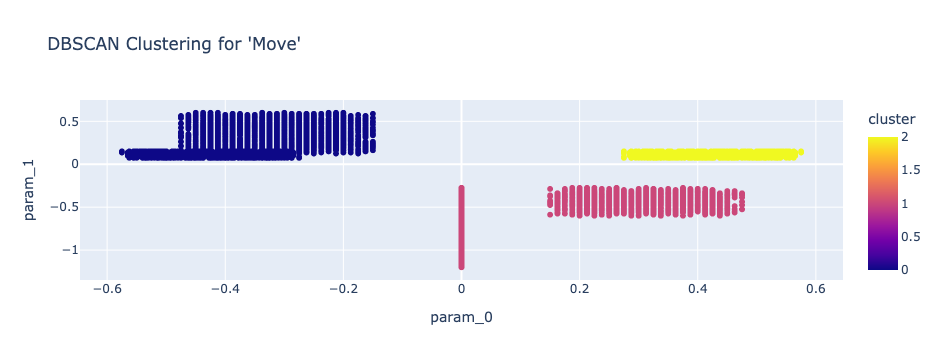

In [8]:
print("\n--- PHASE 2: ABSTRACTION ON CLUSTERED STRUCTURES ---")

# 2.1. Cluster a list of specified structures
# Define which structures you want to attempt to cluster.
structure_names_to_cluster = ["Move"] # CHANGED: Now a list
all_clustered_structures = {}

print(f"\nAttempting to cluster structures: {structure_names_to_cluster}...")

for structure_name in structure_names_to_cluster:
    print(f"\n--- Clustering '{structure_name}' ---")
    
    # Get the parameters for the current structure
    params = structures.get(structure_name)
    if not params:
        print(f"Structure '{structure_name}' not found or is empty. Skipping.")
        continue
        
    df = make_df_from_structure(params)

    if df.empty or df.shape[1] == 0:
        print(f"No float parameters to cluster for '{structure_name}'. Skipping.")
        continue

    # Normalize and cluster using DBSCAN
    X = StandardScaler().fit_transform(df.values)
    # Note: You might need to tune eps and min_samples for different structures
    labels = DBSCAN(eps=0.5, min_samples=10).fit_predict(X)
    df["cluster"] = labels
    
    # Visualize the clusters for the current structure
    num_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"Found {num_clusters_found} clusters for '{structure_name}'.")
    
    fig = px.scatter(
        df, 
        x="param_0", 
        y="param_1" if "param_1" in df.columns else None, 
        color="cluster",
        title=f"DBSCAN Clustering for '{structure_name}'"
    )
    fig.show()

    # Create new, more specific structures based on the clusters found
    cluster_map = defaultdict(list)
    for i, label in enumerate(labels):
        if label != -1:  # Ignore noise points
            # Create a unique name for the new clustered structure
            new_structure_name = f"{structure_name.lower()}_cluster_{label}"
            cluster_map[new_structure_name].append(params[i])
            
    # Add the newly found clusters to our collection
    all_clustered_structures.update(dict(cluster_map))

In [9]:
# 2.2. Create Final Structure Set for Re-training
print("\n------------------------------------")
print(f"\nSaved a total of {len(all_clustered_structures)} new structures from clustering.")

# Start with all the new clustered structures
final_structures = all_clustered_structures.copy()

# Add back all original structures that were NOT targeted for clustering
for key, val in structures.items():
    if key not in structure_names_to_cluster:
        final_structures[key] = val
        
print(f"Created a new set of {len(final_structures)} total structures for re-training.")
print("Final structure keys:", list(final_structures.keys()))


------------------------------------

Saved a total of 3 new structures from clustering.
Created a new set of 12 total structures for re-training.
Final structure keys: ['move_cluster_0', 'move_cluster_1', 'move_cluster_2', 'Union', 'Rect', 'SymRef', 'Union(Move, Rect)', 'Union(Union, SymRef)', 'Union(Move, Move)', 'Union(Union, Union)', 'Union(Rect, Union)', 'Union(Move, Union)']


In [10]:
# 2.3. Find Abstractions on Clustered Structures
print("\nFinding abstractions for the new clustered structures...")
# The rest of the script continues from here without changes
models_v2, _ = find_abstractions(final_structures, retrain_iterations=1, error_threshold=0.01)
print(f"Trained models for {len(models_v2)} new structures.")
create_reconstruction_plot_widget(models_v2, final_structures, threshold=0.01)


Finding abstractions for the new clustered structures...
Iteration 1/1: training model for move_cluster_0 on 4000 structures.
Trained model for move_cluster_0. Final train loss: 0.049546528252817336
Iteration 1/1: training model for move_cluster_1 on 4000 structures.
Trained model for move_cluster_1. Final train loss: 0.025464443401211782
Iteration 1/1: training model for move_cluster_2 on 1000 structures.
Trained model for move_cluster_2. Final train loss: 0.021205904078669846
Iteration 1/1: training model for Rect on 12000 structures.
Trained model for Rect. Final train loss: 0.039124497281823385
Iteration 1/1: training model for Union(Move, Rect) on 2000 structures.
Trained model for Union(Move, Rect). Final train loss: 0.037951210513710976
Iteration 1/1: training model for Union(Move, Move) on 2000 structures.
Trained model for Union(Move, Move). Final train loss: 0.007111307219020091
Iteration 1/1: training model for Union(Rect, Union) on 1000 structures.
Trained model for Union(

### Well-Defined Plots (Reconstruction Quality)

Dropdown(description='Structure:', options=('move_cluster_0', 'move_cluster_1', 'move_cluster_2', 'Rect', 'Uni…

Output()

In [11]:
# 2.4. Apply New Abstractions and Compare
print("\nApplying new, clustered abstractions to the original dataset...")
abstracted_dataset_v2 = integrate_abstractions(dataset, models_v2, error_threshold=0.03)
create_comparison_widget(dataset, abstracted_dataset_v2)


Applying new, clustered abstractions to the original dataset...


### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 51034. 2453 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 3 | Δ=5', 3), ('Index 6 | Δ=5', 6), ('Index 8 | Δ=5', 8), ('In…

Output()

In [12]:
print("--- Dataset Comparison Summary ---")

# Calculate metrics for Original Dataset
original_total_nodes = sum(count_nodes(s) for s in dataset)
original_shapes_count = len(dataset)

print(f"\nOriginal Dataset (Initial State):")
print(f"  Total Nodes: {original_total_nodes}")
print(f"  Total Shapes: {original_shapes_count}")


# Calculate metrics for Phase 1 Abstracted Dataset
abstracted_v1_total_nodes = sum(count_nodes(s) for s in abstracted_dataset_v1)
abstracted_v1_shapes_abstracted_in_phase = sum(1 for s in abstracted_dataset_v1 if contains_abstraction(s))

print(f"\nAfter Phase 1: Base Primitive Abstractions:")
print(f"  Total Nodes: {abstracted_v1_total_nodes}")
print(f"  Nodes Reduced from Original: {original_total_nodes - abstracted_v1_total_nodes}")
print(f"  Shapes Abstracted in this Phase: {abstracted_v1_shapes_abstracted_in_phase} / {original_shapes_count}")


# Calculate metrics for Phase 2 Abstracted Dataset
abstracted_v2_total_nodes = sum(count_nodes(s) for s in abstracted_dataset_v2)
abstracted_v2_shapes_abstracted_in_phase = sum(1 for s in abstracted_dataset_v2 if contains_abstraction(s))

print(f"\nAfter Phase 2: Clustered Primitive Abstractions:")
print(f"  Total Nodes: {abstracted_v2_total_nodes}")
print(f"  Nodes Reduced from Phase 1: {abstracted_v1_total_nodes - abstracted_v2_total_nodes}")
print(f"  Shapes Abstracted in this Phase: {abstracted_v2_shapes_abstracted_in_phase} / {original_shapes_count}")

--- Dataset Comparison Summary ---

Original Dataset (Initial State):
  Total Nodes: 76000
  Total Shapes: 3000

After Phase 1: Base Primitive Abstractions:
  Total Nodes: 51074
  Nodes Reduced from Original: 24926
  Shapes Abstracted in this Phase: 2440 / 3000

After Phase 2: Clustered Primitive Abstractions:
  Total Nodes: 51034
  Nodes Reduced from Phase 1: 40
  Shapes Abstracted in this Phase: 2453 / 3000


In [15]:
# --- Step 13: LPCA-Based Clustering and Abstraction ---

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import numpy as np
import hdbscan

print("\n--- PHASE 3: LPCA-BASED CLUSTERING ---")

structure_names_to_cluster = ["Move"]  # Structures to cluster
all_lpca_clustered = {}

for structure_name in structure_names_to_cluster:
    print(f"\n--- LPCA Clustering '{structure_name}' ---")
    
    param_list = structures.get(structure_name)
    if not param_list:
        print(f"No data for {structure_name}. Skipping.")
        continue

    # Convert to float-only params and make array
    float_params = extract_float_params(param_list)
    float_params = [row for row in float_params if len(row) > 0]
    if len(float_params) == 0:
        print(f"No float parameters for {structure_name}. Skipping.")
        continue

    X = np.array(float_params)
    X_scaled = StandardScaler().fit_transform(X)

    # --- Local PCA / intrinsic dimensionality estimation ---
    # For each point, fit PCA on its k nearest neighbors and estimate local dimensionality
    k = 20  # neighborhood size
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)

    local_dims = []
    for idx_neighbors in indices:
        local_X = X_scaled[idx_neighbors]
        cov = np.cov(local_X.T)
        eigvals, _ = np.linalg.eigh(cov)
        eigvals = np.sort(eigvals)[::-1]
        # Choose number of PCs that account for 95% variance
        cumsum = np.cumsum(eigvals) / np.sum(eigvals)
        d = np.searchsorted(cumsum, 0.95) + 1
        local_dims.append(d)

    # Optional: use local dimension to scale distances or guide clustering
    # Here we use HDBSCAN for clustering with min_cluster_size proportional to local dims
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean')
    labels = clusterer.fit_predict(X_scaled)

    print(f"Found {len(set(labels)) - (1 if -1 in labels else 0)} clusters for '{structure_name}'.")

    # Map points to cluster names
    cluster_map = defaultdict(list)
    for point, label in zip(param_list, labels):
        if label != -1:
            cluster_name = f"{structure_name.lower()}_lpca_{label}"
            cluster_map[cluster_name].append(point)
    all_lpca_clustered.update(dict(cluster_map))



--- PHASE 3: LPCA-BASED CLUSTERING ---

--- LPCA Clustering 'Move' ---
Found 143 clusters for 'Move'.


In [16]:
# --- Step 14: Prepare Final Structure Set ---
final_lpca_structures = all_lpca_clustered.copy()
for key, val in structures.items():
    if key not in structure_names_to_cluster:
        final_lpca_structures[key] = val

print(f"\nTotal structures for LPCA abstraction training: {len(final_lpca_structures)}")
print("Keys:", list(final_lpca_structures.keys()))


Total structures for LPCA abstraction training: 152
Keys: ['move_lpca_130', 'move_lpca_0', 'move_lpca_100', 'move_lpca_84', 'move_lpca_90', 'move_lpca_116', 'move_lpca_85', 'move_lpca_129', 'move_lpca_111', 'move_lpca_115', 'move_lpca_108', 'move_lpca_121', 'move_lpca_131', 'move_lpca_122', 'move_lpca_142', 'move_lpca_119', 'move_lpca_93', 'move_lpca_113', 'move_lpca_91', 'move_lpca_117', 'move_lpca_98', 'move_lpca_94', 'move_lpca_139', 'move_lpca_99', 'move_lpca_110', 'move_lpca_118', 'move_lpca_88', 'move_lpca_123', 'move_lpca_109', 'move_lpca_112', 'move_lpca_136', 'move_lpca_135', 'move_lpca_95', 'move_lpca_140', 'move_lpca_101', 'move_lpca_105', 'move_lpca_96', 'move_lpca_97', 'move_lpca_138', 'move_lpca_102', 'move_lpca_103', 'move_lpca_124', 'move_lpca_134', 'move_lpca_132', 'move_lpca_120', 'move_lpca_92', 'move_lpca_86', 'move_lpca_126', 'move_lpca_107', 'move_lpca_89', 'move_lpca_128', 'move_lpca_106', 'move_lpca_104', 'move_lpca_125', 'move_lpca_87', 'move_lpca_133', 'move_

In [17]:
# --- Step 15: Train Abstractions on LPCA Clusters ---
models_lpca, _ = find_abstractions(final_lpca_structures, retrain_iterations=1, error_threshold=0.01)
print(f"Trained models for {len(models_lpca)} LPCA-clustered structures.")

Iteration 1/1: training model for move_lpca_130 on 69 structures.
Trained model for move_lpca_130. Final train loss: 0.02821241319179535
Iteration 1/1: training model for move_lpca_0 on 2000 structures.
Trained model for move_lpca_0. Final train loss: 0.04748424387071282
Iteration 1/1: training model for move_lpca_100 on 1109 structures.
Trained model for move_lpca_100. Final train loss: 0.022308001708653238
Iteration 1/1: training model for move_lpca_84 on 12 structures.
Trained model for move_lpca_84. Final train loss: 0.00654466450214386
Iteration 1/1: training model for move_lpca_90 on 53 structures.
Trained model for move_lpca_90. Final train loss: 0.030476808547973633
Iteration 1/1: training model for move_lpca_116 on 40 structures.
Trained model for move_lpca_116. Final train loss: 0.01962975040078163
Iteration 1/1: training model for move_lpca_85 on 29 structures.
Trained model for move_lpca_85. Final train loss: 0.014238743111491203
Iteration 1/1: training model for move_lpca_

In [18]:

# --- Step 16: Apply Abstractions ---
abstracted_dataset_lpca = integrate_abstractions(dataset, models_lpca, error_threshold=0.03)

In [19]:
# --- Step 17: Visualize & Compare ---
create_comparison_widget(dataset, abstracted_dataset_lpca)
create_reconstruction_plot_widget(models_lpca, final_lpca_structures, threshold=0.01)

### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 46875. 2871 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 0 | Δ=5', 0), ('Index 1 | Δ=5', 1), ('Index 2 | Δ=5', 2), ('In…

Output()

### Well-Defined Plots (Reconstruction Quality)

Dropdown(description='Structure:', options=('move_lpca_130', 'move_lpca_0', 'move_lpca_100', 'move_lpca_84', '…

Output()

### Abstraction Metrics Comparison

Phase      Total Nodes     Nodes Reduced        Shapes Abstracted   
Base       51074           24926                2440/3000                
DBSCAN     51034           24966                2453/3000                
LPCA       46875           29125                2871/3000                


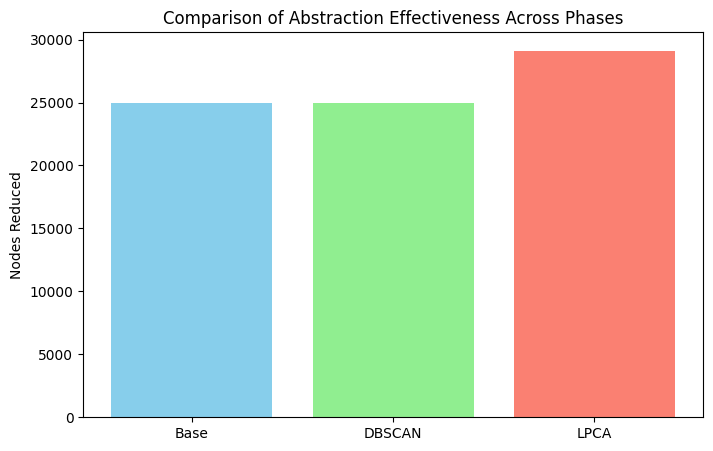

In [20]:
# --- Comparison Metrics Across All Phases ---

phases = {
    "Base": abstracted_dataset_v1,
    "DBSCAN": abstracted_dataset_v2,
    "LPCA": abstracted_dataset_lpca
}

print("### Abstraction Metrics Comparison\n")
print(f"{'Phase':<10} {'Total Nodes':<15} {'Nodes Reduced':<20} {'Shapes Abstracted':<20}")

original_total_nodes = sum(count_nodes(s) for s in dataset)
original_shapes_count = len(dataset)

for phase_name, abs_data in phases.items():
    total_nodes = sum(count_nodes(s) for s in abs_data)
    nodes_reduced = original_total_nodes - total_nodes
    shapes_abstracted = sum(1 for s in abs_data if contains_abstraction(s))
    print(f"{phase_name:<10} {total_nodes:<15} {nodes_reduced:<20} {shapes_abstracted}/{original_shapes_count:<20}")

# Optional: visualize node reductions across phases
import matplotlib.pyplot as plt

nodes = [sum(count_nodes(s) for s in phases[p]) for p in phases]
reduced = [original_total_nodes - n for n in nodes]
labels = list(phases.keys())

plt.figure(figsize=(8,5))
plt.bar(labels, reduced, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel("Nodes Reduced")
plt.title("Comparison of Abstraction Effectiveness Across Phases")
plt.show()

### Chamfer Distance Metrics

Original: Average Chamfer Distance = 0.000398
Base Abstraction: Average Chamfer Distance = nan
DBSCAN Clustering: Average Chamfer Distance = nan
LPCA Clustering: Average Chamfer Distance = nan


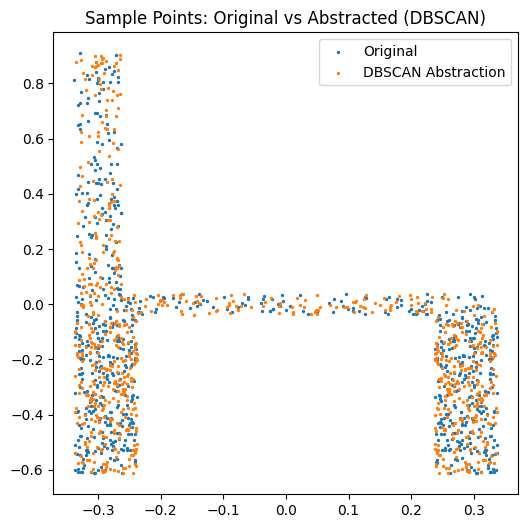

In [22]:
import numpy as np
import torch
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from abstractions.dsl.core import Shape
from abstractions.dsl.nodes import Union, Move, SymRef, SymTrans, Rect

def sample_shape_points(shape: Shape, num_points: int = 500) -> np.ndarray:
    """Recursively samples 2D points from a DSL shape tree."""
    if isinstance(shape, Union):
        left, right = shape.children
        n1 = num_points // 2
        n2 = num_points - n1
        return np.vstack([
            sample_shape_points(left, n1),
            sample_shape_points(right, n2)
        ])
    elif isinstance(shape, Move):
        child, dx, dy = shape.param_tuple()[1]
        pts = sample_shape_points(child, num_points)
        return pts + np.array([dx, dy])
    elif isinstance(shape, SymRef):
        child, axis = shape.param_tuple()[1]
        pts = sample_shape_points(child, num_points)
        if axis == "x":
            reflected = pts * np.array([-1, 1])
        elif axis == "y":
            reflected = pts * np.array([1, -1])
        return np.vstack([pts, reflected])
    elif isinstance(shape, SymTrans):
        child, axis, count, spacing = shape.param_tuple()[1]
        pts = sample_shape_points(child, max(num_points // count, 1))
        all_pts = []
        for i in range(count):
            offset = i * spacing
            dx, dy = (offset, 0) if axis == "x" else (0, offset)
            all_pts.append(pts + np.array([dx, dy]))
        return np.vstack(all_pts)
    elif isinstance(shape, Rect):
        width, height = shape.param_tuple()[1]
        x = np.random.uniform(-width/2, width/2, num_points)
        y = np.random.uniform(-height/2, height/2, num_points)
        return np.stack([x, y], axis=1)
    else:
        return np.zeros((0,2))

def chamfer_distance(points1: np.ndarray, points2: np.ndarray) -> float:
    """Computes bidirectional Chamfer distance between two 2D point clouds."""
    tree1 = cKDTree(points1)
    tree2 = cKDTree(points2)
    d1, _ = tree1.query(points2)
    d2, _ = tree2.query(points1)
    return np.mean(d1**2) + np.mean(d2**2)

# --- Compute Chamfer distance for all phases ---
phases = {
    "Original": dataset,
    "Base Abstraction": abstracted_dataset_v1,
    "DBSCAN Clustering": abstracted_dataset_v2,
    "LPCA Clustering": abstracted_dataset_lpca  # if you have this
}

num_points_per_shape = 500
cd_results = {}

print("### Chamfer Distance Metrics\n")
for phase_name, shapes in phases.items():
    total_cd = 0.0
    for orig_shape, abs_shape in zip(dataset, shapes):
        pts_orig = sample_shape_points(orig_shape, num_points=num_points_per_shape)
        pts_abs  = sample_shape_points(abs_shape, num_points=num_points_per_shape)
        total_cd += chamfer_distance(pts_orig, pts_abs)
    avg_cd = total_cd / len(shapes)
    cd_results[phase_name] = avg_cd
    print(f"{phase_name}: Average Chamfer Distance = {avg_cd:.6f}")

# --- Optional: Plot example shape points ---
example_idx = 0
plt.figure(figsize=(6,6))
plt.scatter(
    sample_shape_points(dataset[example_idx], num_points=num_points_per_shape)[:,0],
    sample_shape_points(dataset[example_idx], num_points=num_points_per_shape)[:,1],
    s=2, label="Original"
)
plt.scatter(
    sample_shape_points(abstracted_dataset_v2[example_idx], num_points=num_points_per_shape)[:,0],
    sample_shape_points(abstracted_dataset_v2[example_idx], num_points=num_points_per_shape)[:,1],
    s=2, label="DBSCAN Abstraction"
)
plt.title("Sample Points: Original vs Abstracted (DBSCAN)")
plt.legend()
plt.show()

In [24]:
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

num_points_per_shape = 300  # Number of points to sample for each shape

# Datasets to compare
datasets_to_compare = {
    "Original": dataset,
    "Base Abstraction": abstracted_dataset_v1,
    "DBSCAN Abstraction": abstracted_dataset_v2,
    "LPCA Abstraction": abstracted_dataset_lpca  # uncomment if available
}

# Dropdown to select shape index
shape_dropdown = widgets.IntSlider(
    value=0,
    min=0,
    max=len(dataset)-1,
    step=1,
    description='Shape Index:',
    continuous_update=False
)

# Output widget
output = widgets.Output()

def update_comparison(idx):
    output.clear_output()
    with output:
        num_phases = len(datasets_to_compare)
        plt.figure(figsize=(5*num_phases, 5))
        for i, (phase_name, shapes) in enumerate(datasets_to_compare.items()):
            plt.subplot(1, num_phases, i+1)
            pts = sample_shape_points(shapes[idx], num_points=num_points_per_shape)
            plt.scatter(pts[:,0], pts[:,1], s=5)
            plt.title(f"{phase_name}\nShape {idx}")
            plt.axis("equal")
            plt.axis("off")
        plt.show()

# Link dropdown to update function
shape_dropdown.observe(lambda change: update_comparison(change['new']), names='value')

# Display
display(Markdown("### Compare Original vs Abstracted Shapes"), shape_dropdown, output)
update_comparison(0)  # Initial display

### Compare Original vs Abstracted Shapes

IntSlider(value=0, continuous_update=False, description='Shape Index:', max=2999)

Output()